#Analisis de Abandono de Clientes (Customer Churn)
#Telco Customer Churn - IBM Dataset

**Proyecto**: Predecir que clientes tienen mayor probabilidad de abandonar el servicio 

#Pregunta de negocio
Que caracteristicaz distinguen a los clientes que abandonan el servicio, y podemos predecir el abandono para dise;ar estrategias de retencion?

#Notebook 1: Analisis Exploratorio de Datos (EDA)
En este Notebook realizamos la inspeccion inical, limpieza y exploracion visual del dataset.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,6)
pd.set_option("display.max_columns",None)
print("Librerias cargadas correctamente")
print(f"Pandas: {pd.__version__}")

Librerias cargadas correctamente
Pandas: 2.3.3


In [2]:
import os 
print(os.listdir("../data"))

['Telco_customer_churn.xlsx']


In [3]:
df=pd.read_excel("../data/Telco_customer_churn.xlsx")

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 7043
Columnas: 33


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

#Gracias al df.info() se detecta que Total Charges esta con un tipo incorrecto ya que deberia ser numerico y no texto.

In [5]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print(f"Valores no-numericos encontrados: {df['Total Charges'].isnull().sum()}")

Valores no-numericos encontrados: 11


In [6]:
df[df["Total Charges"].isnull()]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,No,Yes,No,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [7]:
filas_nulas = df[df["Total Charges"].isnull()]
print(f"Tenure Months de las filas con problemas:")
print(filas_nulas["Tenure Months"].value_counts())

Tenure Months de las filas con problemas:
Tenure Months
0    11
Name: count, dtype: int64


## Los 11 valores nulos encontrados en el Total Charges corresponden a clientes con'Tenure Months'=0 lo que quiere decir que son clientes nuevos sin facturacion acumulada.
## Se decide rellenar con 0 ya que es el valor logicamente correcto (clientes con 0 meses que no han pagado nada)

In [8]:
df["Total Charges"] = df["Total Charges"].fillna(0)

print(f"Nulos despues de limpieza: {df['Total Charges'].isnull().sum()}")
print(f"Tipo de dato: {df['Total Charges'].dtype}")

Nulos despues de limpieza: 0
Tipo de dato: float64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [10]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2279.734304,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.794470,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,398.550000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1394.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


#Analisis de la variable objetivo (churn)
Estudiamos la distribucion del abandono y validamos consistencia entre las columnas relacionadas con churn.

In [11]:
print("Conteo absoluto:")
print(df["Churn Label"].value_counts())
print("\nDistribucion porcentual:")
print((df["Churn Label"].value_counts(normalize=True)*100).round(2))

Conteo absoluto:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Distribucion porcentual:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [12]:
yes_label = (df["Churn Label"] == "Yes").sum()
yes_value = (df["Churn Value"] == 1).sum()

print(f"Churn Label = 'Yes' : [{yes_label}")
print(f"Churn Label = 1 : [{yes_label}")
print(f"Consistentes? = 'Yes' : [{yes_label == yes_value}")



Churn Label = 'Yes' : [1869
Churn Label = 1 : [1869
Consistentes? = 'Yes' : [True


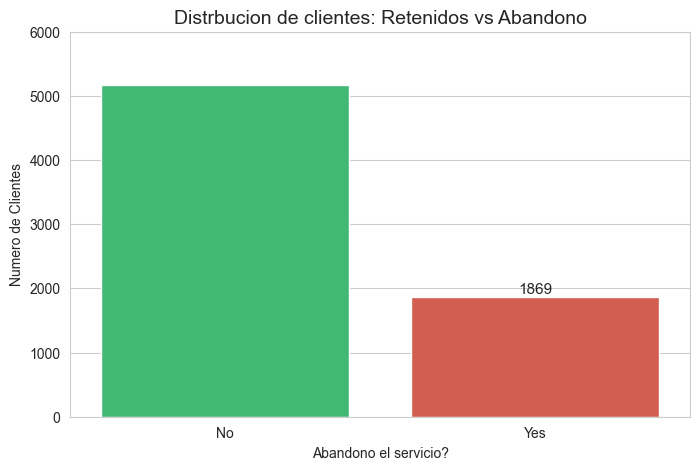

In [13]:
#Distribucion visual del Churn
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Churn Label",
    hue="Churn Label",
    palette={"No": "#2ecc71", "Yes": "#e74c3c"},
    order=["No", "Yes"],
    legend=False
)

plt.title("Distrbucion de clientes: Retenidos vs Abandono", fontsize=14)
plt.xlabel("Abandono el servicio?")
plt.ylabel("Numero de Clientes")
plt.ylim(0,6000)

for container in ax.containers:
   ax.bar_label(container, fontsize=11)

   plt.show()

### 📌 Hallazgo 1: Tasa de churn observada

De los 7,043 clientes analizados, **1,869 abandonaron el servicio (26.5%)**.

**Contexto importante:** este valor representa el churn acumulado del período cubierto por el dataset, no una tasa anualizada comparable directamente con benchmarks de industria. El dataset no especifica el período de medición exacto. 

En el sector telecomunicaciones, las tasas de churn anuales varían ampliamente según el segmento (10-25% en postpago, 30-50%+ en prepago), por lo que sin un benchmark interno de la empresa, no podemos afirmar de forma absoluta si 26.5% es alto o bajo.

**Lo accionable:** dentro del propio dataset existen diferencias dramáticas entre segmentos, lo cual permite priorizar acciones de retención independientemente del valor absoluto.

**Implicación para el modelado:** la clase positiva (Yes) representa el 26.5% del dataset. El desbalance debe manejarse con técnicas apropiadas (class weights, métricas como recall y F1).



In [14]:
##Analisis bivariado: tipo de contrato vs Churn
##El tipo de contrato es una de las variables mas relevantes en negocios de suscripcion. Analizamos si existen diferencias significativas en la tasa de abandono segun el plan contractual del cliente.


In [15]:
print("Distribucion de tipos de contrato:")
print(df["Contract"].value_counts())
print("\nProporcion (%):")
print((df["Contract"].value_counts(normalize=True) * 100).round(2))

Distribucion de tipos de contrato:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Proporcion (%):
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64


In [16]:
churn_por_contrato = df.groupby("Contract")["Churn Value"].agg(["count","sum","mean"])
churn_por_contrato.columns = ["Total clientes", "Abandonaron", "Tasa de churn"]
churn_por_contrato["Tasa de churn"] = (churn_por_contrato["Tasa de churn"] * 100).round(2)
churn_por_contrato = churn_por_contrato.reindex(["Month-to-month", "One year", "Two year"])

print(churn_por_contrato)

                Total clientes  Abandonaron  Tasa de churn
Contract                                                  
Month-to-month            3875         1655          42.71
One year                  1473          166          11.27
Two year                  1695           48           2.83


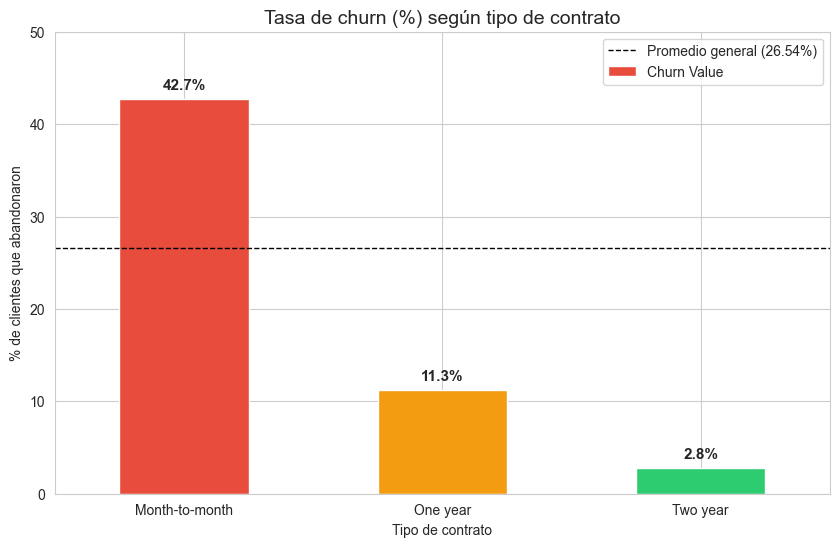

In [17]:
# Gráfico: tasa de churn por tipo de contrato
plt.figure(figsize=(10, 6))

tasas = df.groupby("Contract")["Churn Value"].mean() * 100
tasas = tasas.reindex(["Month-to-month", "One year", "Two year"])

ax = tasas.plot(kind="bar", color=["#e74c3c", "#f39c12", "#2ecc71"])
plt.title("Tasa de churn (%) según tipo de contrato", fontsize=14)
plt.ylabel("% de clientes que abandonaron")
plt.xlabel("Tipo de contrato")
plt.xticks(rotation=0)
plt.axhline(y=26.54, color="black", linestyle="--", linewidth=1, label="Promedio general (26.54%)")
plt.legend()

# Etiquetas con porcentajes encima de cada barra
for i, v in enumerate(tasas):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.ylim(0, 50)
plt.show()


#Analisis de antiguedad (tenure) vs churn
Analizamos si el tiempo que un cliente lleva con la empresa se relaciona con su probabilidad de abandono.

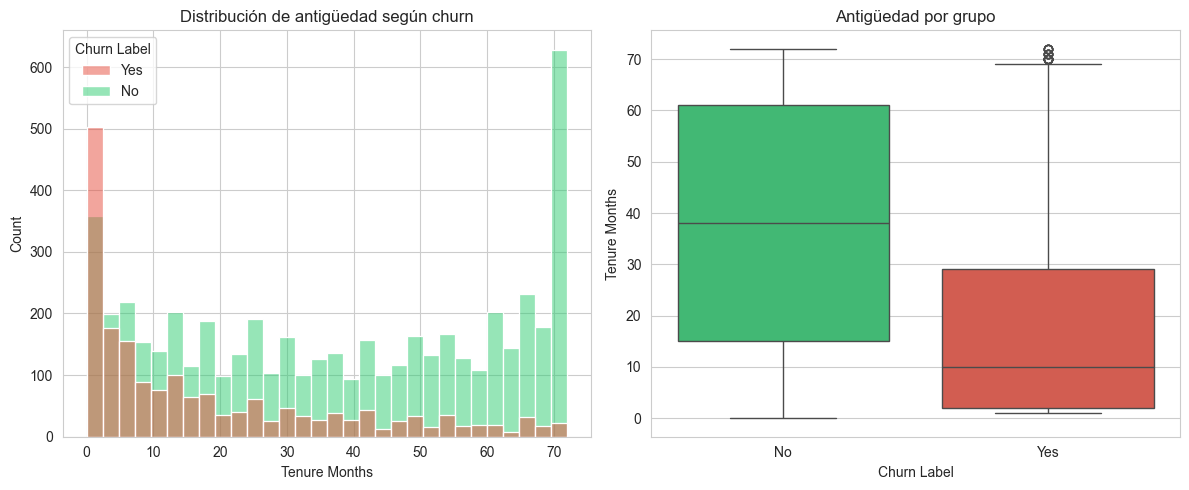

In [18]:
# Comparación de antigüedad entre los que se van y los que se quedan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x="Tenure Months", hue="Churn Label",
palette={"No": "#2ecc71", "Yes": "#e74c3c"}, bins=30)
plt.title("Distribución de antigüedad según churn")

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x="Churn Label", y="Tenure Months",
hue="Churn Label", palette={"No": "#2ecc71", "Yes": "#e74c3c"},
order=["No", "Yes"], legend=False)
plt.title("Antigüedad por grupo")

plt.tight_layout()
plt.show()


In [19]:
# Comparación numérica
print("Antigüedad promedio (meses):")
print(df.groupby("Churn Label")["Tenure Months"].agg(["mean", "median"]).round(1))


Antigüedad promedio (meses):
             mean  median
Churn Label              
No           37.6    38.0
Yes          18.0    10.0


In [20]:
df.groupby("Payment Method")["Churn Value"].mean() * 100

Payment Method
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn Value, dtype: float64

### 📌 Hallazgo 4: El pago con cheque electrónico se asocia a alto churn

Tasa de churn por método de pago:
- Electronic check: **45.3%** (muy por encima del promedio)
- Mailed check: 19.1%
- Bank transfer (automatic): 16.7%
- Credit card (automatic): 15.2%

Los métodos automáticos tienen el churn más bajo. Sin embargo, la diferencia no se explica solo por "automático vs manual": el mailed check (también manual) tiene churn moderado (19%), mientras que el electronic check se dispara al 45%.

**Cautela analítica:** esta asociación NO implica causalidad. El electronic check probablemente actúa como marcador de un perfil de cliente (posiblemente correlacionado con contrato mes-a-mes y baja antigüedad). Requiere análisis cruzado para confirmar. Cambiar el método de pago por sí solo no necesariamente reduciría el churn.


In [21]:
pd.crosstab(df["Payment Method"], df["Contract"], normalize="index") * 100

Contract,Month-to-month,One year,Two year
Payment Method,,,
Bank transfer (automatic),38.147668,25.323834,36.528497
Credit card (automatic),35.676741,26.149803,38.173456
Electronic check,78.224101,14.672304,7.103594
Mailed check,55.397022,20.905707,23.697270


### 📌 Hallazgo 4b: El método de pago es un síntoma, no una causa

Tabla cruzada (% de cada método de pago según tipo de contrato):

| Método de pago | Month-to-month | One year | Two year |
|---|---|---|---|
| Electronic check | **78.2%** | 14.7% | 7.1% |
| Mailed check | 55.4% | 20.9% | 23.7% |
| Bank transfer (auto) | 38.1% | 25.3% | 36.5% |
| Credit card (auto) | 35.7% | 26.1% | 38.2% |

El 78% de los clientes que pagan con cheque electrónico tienen contrato mes-a-mes, el segmento de mayor churn (Hallazgo 2). 

**Conclusión:** el alto churn asociado al cheque electrónico se explica por su correlación con el contrato mes-a-mes, no por el método de pago en sí. Forzar un cambio de método de pago probablemente no reduciría el churn; la palanca real es el tipo de contrato.


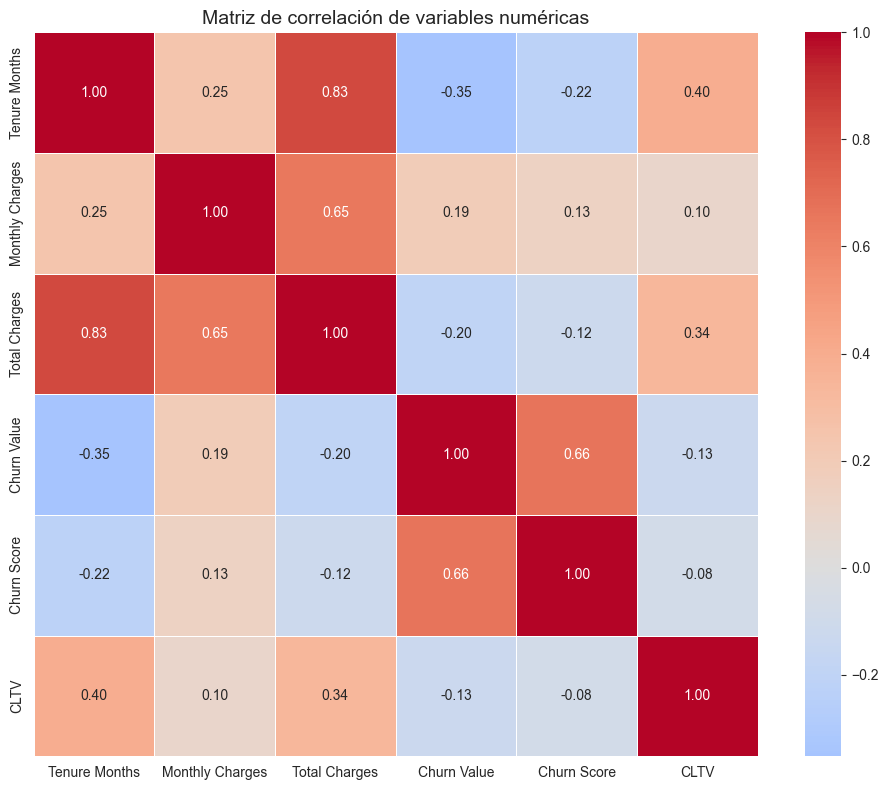

In [22]:
#Matriz de correlación entre variables numéricas

#Analizamos cómo se relacionan entre sí las variables numéricas, y cuáles se asocian más con el churn. Valores cercanos a 1 o -1 indican relación fuerte; cercanos a 0, relación débil.


# Seleccionar solo columnas numéricas relevantes (excluyendo identificadores)
columnas_numericas = ["Tenure Months", "Monthly Charges", "Total Charges",
"Churn Value", "Churn Score", "CLTV"]

# Calcular la matriz de correlación
matriz_corr = df[columnas_numericas].corr()

# Visualizar como heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
matriz_corr,
annot=True, # muestra los números en cada celda
cmap="coolwarm", # rojo = positivo, azul = negativo
center=0, # el blanco queda en 0
fmt=".2f", # 2 decimales
square=True,
linewidths=0.5
)
plt.title("Matriz de correlación de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Resumen de hallazgos del EDA

### Hallazgos principales

1. **Tasa de churn observada: 26.5%** (1,869 de 7,043 clientes). Valor que debe interpretarse con cautela sin un benchmark interno o período definido.

2. **El tipo de contrato es el driver más fuerte:** mes-a-mes 42.7% de churn vs. 2.8% en contratos de 2 años. Diferencia de ~15x.

3. **La antigüedad discrimina fuertemente:** los que se van tienen mediana de 10 meses; los que se quedan, 38 meses. El riesgo se concentra en los primeros meses.

4. **El método de pago es un síntoma, no una causa:** el cheque electrónico mostraba 45% de churn, pero el 78% de esos clientes son mes-a-mes. La asociación se explica por el contrato, no por el método de pago.

5. **Correlaciones numéricas:** Tenure es el predictor legítimo más fuerte (-0.35).

### Banderas para el modelado

- **Data leakage:** excluir `Churn Score` (correlación 0.66, calculada con info del churn).
- **Multicolinealidad:** `Tenure Months` y `Total Charges` correlacionan 0.83.
- **Desbalance:** clase positiva 26.5%; usar class weights o métricas como recall/F1.
- **Columnas a descartar:** identificadores (CustomerID), geográficas (Lat/Long, Zip), y `Count`.

### Próximos pasos (Semana 2)
Validación estadística de los hallazgos: pruebas de chi-cuadrado (categóricas) y t-test (numéricas) para confirmar que las diferencias observadas son estadísticamente significativas.


## Semana 2 — Validación estadística

### Prueba chi-cuadrado: Contrato vs Churn

Confirmamos si la relación entre tipo de contrato y churn es estadísticamente significativa o pudo deberse al azar.

- H0 (hipótesis nula): no hay relación entre contrato y churn.
- H1 (hipótesis alternativa): sí hay relación.




In [23]:
from scipy.stats import chi2_contingency 

# Tabla de contingencia: contrato vs churn 
tabla = pd.crosstab(df["Contract"], df["Churn Label"])
print("Tabla de contingencia:")
print(tabla)

#Prueba chi_cuadrado
chi2,p_valor,gl,esperados = chi2_contingency(tabla)

print(f"\nEstadistico chi-cuadrado:{chi2:.2f}")
print(f"P-valor:{p_valor}")
print(f"Grados de libertad:{gl}")

if p_valor < 0.05:
   print("\n✓ Resultado: la relación ES estadísticamente significativa (rechazamos H0)")
else:
   print("\n✗ Resultado: no hay evidencia de relación significativa")


Tabla de contingencia:
Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48

Estadistico chi-cuadrado:1184.60
P-valor:5.863038300673391e-258
Grados de libertad:2

✓ Resultado: la relación ES estadísticamente significativa (rechazamos H0)


### Resultado: Contrato vs Churn (chi-cuadrado)

- Estadístico chi²: 1184.60
- p-valor: 5.86e-258 (prácticamente 0)
- Decisión: rechazamos H0

**Conclusión:** la relación entre tipo de contrato y churn es estadísticamente significativa (p < 0.001). La diferencia observada en el EDA no se debe al azar. El efecto es además grande (42.7% vs 2.8% de churn), confirmando que el contrato es un driver real y relevante del abandono.


### Prueba t-test: Antigüedad (Tenure) vs Churn

Comparamos la antigüedad promedio entre los clientes que abandonaron y los que permanecieron.

- H0: la antigüedad promedio es igual en ambos grupos.
- H1: la antigüedad promedio difiere entre los grupos.


In [24]:
from scipy.stats import ttest_ind

# Separar la antigüedad en dos grupos según churn
tenure_churn = df[df["Churn Label"] == "Yes"]["Tenure Months"]
tenure_no_churn = df[df["Churn Label"] == "No"]["Tenure Months"]

# Promedios de cada grupo
print(f"Antigüedad promedio - Se van (Yes): {tenure_churn.mean():.1f} meses")
print(f"Antigüedad promedio - Se quedan (No): {tenure_no_churn.mean():.1f} meses")

# Prueba t-test
t_stat, p_valor = ttest_ind(tenure_churn, tenure_no_churn)

print(f"\nEstadístico t: {t_stat:.2f}")
print(f"P-valor: {p_valor}")

if p_valor < 0.05:
   print("\n✓ Resultado: la diferencia ES estadísticamente significativa (rechazamos H0)")
else:
   print("\n✗ Resultado: no hay evidencia de diferencia significativa")



Antigüedad promedio - Se van (Yes): 18.0 meses
Antigüedad promedio - Se quedan (No): 37.6 meses

Estadístico t: -31.58
P-valor: 7.999057960590134e-205

✓ Resultado: la diferencia ES estadísticamente significativa (rechazamos H0)


## Resumen de validación estadística

Para confirmar que los patrones observados en el análisis exploratorio no se deben al azar, se aplicaron pruebas de significancia estadística sobre los dos hallazgos principales. En ambos casos se utilizó un nivel de significancia de 0.05.

### Prueba 1: Tipo de contrato vs Churn (Chi-cuadrado)

Se aplicó la prueba chi-cuadrado por tratarse de dos variables categóricas.

- Estadístico chi²: 1184.60
- p-valor: 5.86e-258 (prácticamente 0)
- Decisión: se rechaza la hipótesis nula

La relación entre el tipo de contrato y el churn es estadísticamente significativa (p < 0.001). La diferencia observada en el EDA (42.7% de churn en contratos mes-a-mes frente a 2.8% en contratos de dos años) no es producto del azar y refleja un patrón real en los datos.

### Prueba 2: Antigüedad (Tenure) vs Churn (t-test)

Se aplicó la prueba t para muestras independientes, comparando la antigüedad promedio (variable numérica) entre los dos grupos definidos por el churn (variable categórica).

- Antigüedad promedio: 18.0 meses (clientes que se van) vs 37.6 meses (clientes que permanecen)
- Estadístico t: -31.58
- p-valor: 7.99e-205 (prácticamente 0)
- Decisión: se rechaza la hipótesis nula

La diferencia de antigüedad entre ambos grupos es estadísticamente significativa (p < 0.001) y de gran magnitud: los clientes que abandonan llevan, en promedio, menos de la mitad del tiempo que los que permanecen.

### Conclusión general

Ambos hallazgos del análisis exploratorio quedan confirmados con respaldo estadístico formal. El tipo de contrato y la antigüedad del cliente son factores asociados al churn de manera significativa y con un tamaño de efecto relevante, no solo estadísticamente detectable. Estos resultados justifican su inclusión como variables predictoras en la fase de modelado.


## Resumen de validación estadística

Para confirmar que los patrones observados en el análisis exploratorio no se deben al azar, se aplicaron pruebas de significancia estadística sobre los dos hallazgos principales. En ambos casos se utilizó un nivel de significancia de 0.05.

### Prueba 1: Tipo de contrato vs Churn (Chi-cuadrado)

Se aplicó la prueba chi-cuadrado por tratarse de dos variables categóricas.

- Estadístico chi²: 1184.60
- p-valor: 5.86e-258 (prácticamente 0)
- Decisión: se rechaza la hipótesis nula

La relación entre el tipo de contrato y el churn es estadísticamente significativa (p < 0.001). La diferencia observada en el EDA (42.7% de churn en contratos mes-a-mes frente a 2.8% en contratos de dos años) no es producto del azar y refleja un patrón real en los datos.

### Prueba 2: Antigüedad (Tenure) vs Churn (t-test)

Se aplicó la prueba t para muestras independientes, comparando la antigüedad promedio (variable numérica) entre los dos grupos definidos por el churn (variable categórica).

- Antigüedad promedio: 18.0 meses (clientes que se van) vs 37.6 meses (clientes que permanecen)
- Estadístico t: -31.58
- p-valor: 7.99e-205 (prácticamente 0)
- Decisión: se rechaza la hipótesis nula

La diferencia de antigüedad entre ambos grupos es estadísticamente significativa (p < 0.001) y de gran magnitud: los clientes que abandonan llevan, en promedio, menos de la mitad del tiempo que los que permanecen.

### Conclusión general

Ambos hallazgos del análisis exploratorio quedan confirmados con respaldo estadístico formal. El tipo de contrato y la antigüedad del cliente son factores asociados al churn de manera significativa y con un tamaño de efecto relevante, no solo estadísticamente detectable. Estos resultados justifican su inclusión como variables predictoras en la fase de modelado.


## Semana 3 — Preparación de datos para el modelado

Convertimos las variables categóricas a formato numérico para que los modelos puedan procesarlas. Trabajamos sobre una copia para preservar el dataset original.


In [25]:
### Paso 1: Eliminar columnas que no aportan al modelo

# Copia para no alterar el dataframe original
df_model = df.copy()

# Eliminar columnas que no aportan al modelo
columnas_a_eliminar = [
"CustomerID", "Count", "Country", "State", "City", "Zip Code",
"Lat Long", "Latitude", "Longitude", # geográficas / identificadores
"Churn Label", # redundante con Churn Value
"Churn Score", # DATA LEAKAGE (detectado en el heatmap)
"Churn Reason", # solo existe para los que se fueron
"CLTV" # derivada, puede sesgar
]

df_model = df_model.drop(columns=columnas_a_eliminar)

print(f"Columnas restantes: {df_model.shape[1]}")
print(df_model.columns.tolist())


Columnas restantes: 20
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [26]:
# Detectar columnas binarias Yes/No
columnas_binarias = []
for col in df_model.columns:
   valores = set(df_model[col].dropna().unique())
   if valores <= {"Yes", "No"}:
     columnas_binarias.append(col)

print("Columnas binarias Yes/No encontradas:")
print(columnas_binarias)

# Convertir Yes -> 1, No -> 0
for col in columnas_binarias:
  df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

print("\nConvertidas correctamente")
df_model[columnas_binarias].head()


Columnas binarias Yes/No encontradas:
['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']

Convertidas correctamente


,Senior Citizen,Partner,Dependents,Phone Service,Paperless Billing
0,0,0,0,1,1
1,0,0,1,1,1
2,0,0,1,1,1
3,0,1,1,1,1
4,0,0,1,1,1


In [27]:
# Identificar columnas categóricas que quedan (tipo object)
columnas_categoricas = df_model.select_dtypes(include="object").columns.tolist()
print("Columnas categóricas restantes para one-hot encoding:")
print(columnas_categoricas)

# Aplicar one-hot encoding
df_model = pd.get_dummies(df_model, columns=columnas_categoricas, drop_first=False)

print(f"\nForma del dataset después del encoding: {df_model.shape}")
print(f"\nNuevas columnas creadas:")
print(df_model.columns.tolist())


Columnas categóricas restantes para one-hot encoding:
['Gender', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']

Forma del dataset después del encoding: (7043, 42)

Nuevas columnas creadas:
['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Gender_Female', 'Gender_Male', 'Multiple Lines_No', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_DSL', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_

In [28]:
# Confirmar que todo es numérico
print("Tipos de datos en el dataset preparado:")
print(df_model.dtypes.value_counts())

# Verificar que no hay nulos
print(f"\nNulos totales: {df_model.isnull().sum().sum()}")

# Ver las primeras filas del dataset listo
df_model.head()


Tipos de datos en el dataset preparado:
bool       33
int64       7
float64     2
Name: count, dtype: int64

Nulos totales: 0


,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,Gender_Female,Gender_Male,Multiple Lines_No,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Online Security_No,Online Security_No internet service,Online Security_Yes,Online Backup_No,Online Backup_No internet service,Online Backup_Yes,Device Protection_No,Device Protection_No internet service,Device Protection_Yes,Tech Support_No,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,0,0,0,2,1,1,53.85,108.15,1,False,True,True,False,False,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
1,0,0,1,2,1,1,70.70,151.65,1,True,False,True,False,False,False,True,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
2,0,0,1,8,1,1,99.65,820.50,1,True,False,False,False,True,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False
3,0,1,1,28,1,1,104.80,3046.05,1,True,False,False,False,True,False,True,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,True,True,False,False,False,False,True,False
4,0,0,1,49,1,1,103.70,5036.30,1,False,True,False,False,True,False,True,False,True,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True,True,False,False,True,False,False,False


In [29]:
## Semana 3 — Modelado

### Paso 1: Separar variables predictoras (X) y objetivo (y)


In [30]:
# X = todas las columnas excepto el objetivo
# y = la columna que queremos predecir
X = df_model.drop(columns=["Churn Value"])
y = df_model["Churn Value"]

print(f"X (predictoras): {X.shape[0]} filas, {X.shape[1]} columnas")
print(f"y (objetivo): {y.shape[0]} valores")
print(f"\nDistribución del objetivo:")
print(y.value_counts(normalize=True).round(3) * 100)



X (predictoras): 7043 filas, 41 columnas
y (objetivo): 7043 valores

Distribución del objetivo:
Churn Value
0    73.5
1    26.5
Name: proportion, dtype: float64


In [31]:
### Paso 2: Dividir en entrenamiento (train) y prueba (test)

from sklearn.model_selection import train_test_split

# Dividir 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2, # 20% para prueba
random_state=42, # semilla para resultados reproducibles
stratify=y # mantiene la proporción de churn en ambos grupos
)

print(f"Entrenamiento: {X_train.shape[0]} clientes")
print(f"Prueba: {X_test.shape[0]} clientes")
print(f"\nProporción de churn en train: {y_train.mean()*100:.1f}%")
print(f"Proporción de churn en test: {y_test.mean()*100:.1f}%")


Entrenamiento: 5634 clientes
Prueba: 1409 clientes

Proporción de churn en train: 26.5%
Proporción de churn en test: 26.5%


### Paso 3: Entrenar el primer modelo — Regresión Logística

Usamos `class_weight="balanced"` para manejar el desbalance de clases (26.5% churn).


In [32]:
from sklearn.linear_model import LogisticRegression

# Crear el modelo
modelo = LogisticRegression(
max_iter=1000, # iteraciones para que converja
class_weight="balanced", # compensa el desbalance de clases
random_state=42
)

# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")


Modelo entrenado correctamente


c:\Python3.13.2\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Paso 4: Evaluar el modelo en datos de prueba

Usamos el modelo para predecir sobre los 1409 clientes de test (que nunca vio) y medimos qué tan bien acierta.


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# El modelo predice sobre los datos de prueba
y_pred = modelo.predict(X_test)

# Precisión general
print(f"Accuracy (precisión general): {accuracy_score(y_test, y_pred)*100:.1f}%\n")

# Reporte detallado
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"]))


Accuracy (precisión general): 74.5%

Reporte de clasificación:
              precision    recall  f1-score   support

    No churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



### Resultado: Regresión Logística

| Métrica (clase Churn) | Valor |
|---|---|
| Recall | 0.78 |
| Precision | 0.51 |
| F1-score | 0.62 |
| Accuracy general | 0.75 |

**Interpretación:** el modelo detecta el 78% de los clientes que realmente abandonan (recall), lo cual es la métrica prioritaria en un problema de retención. La precision de 0.51 implica falsas alarmas, un trade-off aceptable dado que el costo de no detectar un cliente en riesgo supera el de una alerta innecesaria. El accuracy (75%) no es la métrica relevante por el desbalance de clases: un modelo trivial que prediga "no churn" alcanzaría 73.5% sin detectar a nadie.


### Paso 5: Importancia de variables (Regresión Logística)

Analizamos qué características pesan más en las predicciones del modelo, y comparamos con los hallazgos del EDA.


In [34]:
import numpy as np

# Coeficientes del modelo (uno por cada característica)
coeficientes = pd.DataFrame({
"Variable": X_train.columns,
"Coeficiente": modelo.coef_[0]
})

# Ordenar por valor absoluto (peso, sin importar dirección)
coeficientes["Peso_abs"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values("Peso_abs", ascending=False)

# Top 15 variables más influyentes
print("Top 15 variables más influyentes:")
print(coeficientes.head(15)[["Variable", "Coeficiente"]].to_string(index=False))


Top 15 variables más influyentes:
                       Variable  Coeficiente
                     Dependents    -1.638614
        Contract_Month-to-month     0.736324
              Contract_Two year    -0.691986
              Paperless Billing     0.325744
   Internet Service_Fiber optic     0.309506
Payment Method_Electronic check     0.285612
                        Partner     0.278934
           Internet Service_DSL    -0.267129
             Online Security_No     0.225582
              Multiple Lines_No    -0.221814
                  Phone Service    -0.210263
                Tech Support_No     0.209165
Multiple Lines_No phone service     0.187729
            Online Security_Yes    -0.183205
               Tech Support_Yes    -0.166788


### Importancia de variables (Regresión Logística)

Top variables por peso:
- Dependents (-1.64): protege fuerte contra churn (hallazgo nuevo)
- Contract_Month-to-month (+0.74): empuja al churn ✓ confirma EDA
- Contract_Two year (-0.69): protege ✓ confirma EDA
- Internet Service_Fiber optic (+0.31): empuja ✓ confirma sospecha del EDA
- Payment Method_Electronic check (+0.29): empuja (síntoma del contrato)

**Confirmación del EDA:** las variables de contrato aparecen como predictores fuertes y en la dirección esperada, validando los hallazgos exploratorios.

**Limitación:** al no escalar las variables, los coeficientes no son comparables en magnitud (Tenure no aparece en el top pese a ser relevante). El Random Forest dará una medida de importancia más directa.


### Paso 6: Segundo modelo — Random Forest

Entrenamos un Random Forest y comparamos su desempeño e importancia de variables con la regresión logística.


In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Crear y entrenar el modelo
rf = RandomForestClassifier(
n_estimators=200, # número de árboles
class_weight="balanced", # maneja el desbalance
random_state=42
)
rf.fit(X_train, y_train)

# Predecir sobre test
y_pred_rf = rf.predict(X_test)

# Evaluar
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.1f}%\n")
print("Reporte de clasificación - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=["No churn", "Churn"]))



Accuracy: 78.8%

Reporte de clasificación - Random Forest:
              precision    recall  f1-score   support

    No churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### Comparación de modelos

| Métrica (clase Churn) | Reg. Logística | Random Forest |
|---|---|---|
| Recall | **0.78** | 0.49 |
| Precision | 0.51 | **0.63** |
| F1-score | **0.62** | 0.55 |
| Accuracy | 0.75 | **0.79** |

**Conclusión:** aunque el Random Forest tiene mejor accuracy (79% vs 75%), la Regresión Logística es superior para el objetivo de retención porque detecta el 78% de los clientes que abandonan (recall), frente al 49% del Random Forest. 

En un problema de churn, el recall de la clase positiva es la métrica prioritaria: el costo de no detectar a un cliente en riesgo supera el de una falsa alarma. Por tanto, **se selecciona la Regresión Logística** como modelo principal, sin perjuicio de que el Random Forest podría afinarse (ajuste de umbral o hiperparámetros) para mejorar su recall.


In [36]:
# Importancia de variables del Random Forest
importancias = pd.DataFrame({
"Variable": X_train.columns,
"Importancia": rf.feature_importances_
}).sort_values("Importancia", ascending=False)

print("Top 15 variables más importantes (Random Forest):")
print(importancias.head(15).to_string(index=False))



Top 15 variables más importantes (Random Forest):
                       Variable  Importancia
                  Total Charges     0.142467
                  Tenure Months     0.127916
                Monthly Charges     0.125078
        Contract_Month-to-month     0.076581
                     Dependents     0.045007
                Tech Support_No     0.038299
             Online Security_No     0.035081
              Contract_Two year     0.034359
Payment Method_Electronic check     0.028543
   Internet Service_Fiber optic     0.024221
              Paperless Billing     0.022483
                        Partner     0.021671
                 Senior Citizen     0.016630
               Online Backup_No     0.016402
                    Gender_Male     0.015624


### Importancia de variables (Random Forest)

Top variables:
- Total Charges (0.142)
- Tenure Months (0.128) ← confirma Hallazgo 3 del EDA
- Monthly Charges (0.125)
- Contract_Month-to-month (0.077) ← confirma Hallazgo 2

**Validación del EDA:** el Random Forest, cuya medida de importancia no depende de la escala de las variables, sitúa Tenure Months en el segundo lugar, confirmando que la antigüedad es un driver clave (cosa que la regresión logística "ocultaba" por no escalar las variables). En conjunto, ambos modelos validan los hallazgos del análisis exploratorio: contrato, antigüedad y cargos son los principales factores asociados al churn.


## Resumen del modelado (Semana 3)

### Modelos entrenados
Se entrenaron dos modelos de clasificación con `class_weight="balanced"` para manejar el desbalance de clases (26.5% churn):

| Métrica (clase Churn) | Reg. Logística | Random Forest |
|---|---|---|
| Recall | 0.78 | 0.49 |
| Precision | 0.51 | 0.63 |
| F1-score | 0.62 | 0.55 |
| Accuracy | 0.75 | 0.79 |

### Modelo seleccionado
Se elige la **Regresión Logística** como modelo principal. Aunque el Random Forest tiene mayor accuracy, la Regresión Logística detecta el 78% de los clientes que abandonan (recall), métrica prioritaria en retención: el costo de no detectar un cliente en riesgo supera el de una falsa alarma.

### Validación de los hallazgos del EDA
Ambos modelos confirman los drivers identificados en el análisis exploratorio:
- **Contrato** (mes-a-mes empuja al churn): confirmado en ambos modelos.
- **Antigüedad / Tenure**: segundo lugar en importancia del Random Forest, confirmando el Hallazgo 3.
- **Cargos y tipo de internet**: entre los factores más relevantes.

La coherencia entre el EDA (análisis visual) y dos modelos independientes refuerza la validez de las conclusiones.


# Resumen Ejecutivo — Análisis de Abandono de Clientes (Churn)

## Problema de negocio
La empresa enfrenta la pérdida de clientes (churn). Este análisis busca identificar qué clientes tienen mayor probabilidad de abandonar el servicio y por qué, para diseñar acciones de retención focalizadas.

## Hallazgos principales

**1. Tasa de churn observada: 26.5%** (1.869 de 7.043 clientes). El valor debe interpretarse con cautela: representa el churn acumulado del período del dataset, no una tasa anualizada comparable con benchmarks externos.

**2. El tipo de contrato es el principal factor de abandono.** Los clientes con contrato mes-a-mes presentan 42.7% de churn, frente a 2.8% en contratos de dos años: una diferencia de ~15 veces. Confirmado estadísticamente (chi-cuadrado, p < 0.001).

**3. El riesgo se concentra en los clientes nuevos.** Quienes abandonan llevan en promedio 18 meses; quienes permanecen, 37.6. El churn se acumula en los primeros meses de la relación. Confirmado estadísticamente (t-test, p < 0.001).

**4. El método de pago es un síntoma, no una causa.** El pago con cheque electrónico se asociaba a alto churn (45%), pero el 78% de esos clientes son mes-a-mes. La asociación se explica por el tipo de contrato, no por el método de pago en sí.

**5. Validación con modelos predictivos.** Se entrenaron dos modelos (Regresión Logística y Random Forest). Ambos confirmaron de forma independiente los factores identificados en el análisis exploratorio: contrato, antigüedad y cargos. El modelo seleccionado (Regresión Logística) detecta el 78% de los clientes que abandonan, métrica prioritaria para retención.

## Recomendaciones

**1. Programa de incentivos para clientes mes-a-mes de alto riesgo.**
Ofrecer un beneficio (descuento temporal o acceso ampliado a servicios) condicionado a la migración hacia contratos más largos. La focalización es clave: el modelo predictivo permite dirigir el incentivo solo a los clientes mes-a-mes con mayor probabilidad de abandono, evitando gasto en clientes que permanecerían de todos modos. El diseño específico del incentivo (monto, duración, y si se comunica al inicio o al vencimiento del contrato) requiere un análisis financiero complementario que cruce el costo del incentivo con el valor del cliente (CLTV) y los márgenes por servicio, datos no disponibles en este dataset.

**2. Programa de acompañamiento (onboarding) en los primeros 90 días.**
Dado que el abandono se concentra en clientes nuevos, reforzar la experiencia inicial: seguimiento proactivo, instalación impecable y educación sobre el uso del servicio. El objetivo es asegurar una primera experiencia positiva que reduzca el churn temprano. Esta recomendación complementa la anterior: una apela al incentivo económico, la otra a la satisfacción del cliente.

**3. Investigar el churn elevado en fibra óptica (línea de investigación).**
Los clientes de fibra óptica (servicio premium) presentan churn superior al esperado, un patrón contraintuitivo que requiere análisis adicional antes de definir acciones. Se recomienda examinar: (a) la relación precio/valor percibido frente a la competencia, (b) posibles problemas técnicos o de experiencia específicos del servicio, y (c) si el churn se explica por correlación con otros factores como el tipo de contrato. Requiere datos de costos, satisfacción y benchmarking no disponibles en el dataset actual.

## Limitaciones y próximos pasos
- El dataset no incluye datos financieros (revenue por contrato, costos), necesarios para dimensionar el retorno de las acciones de retención.
- El dataset no especifica el período de medición del churn, lo que limita la comparación con benchmarks de industria.
- Próximos pasos sugeridos: análisis financiero de rentabilidad de los incentivos, investigación específica del segmento de fibra óptica, y eventual despliegue del modelo en producción para generar listas de riesgo periódicas para el equipo de retención.

## Nota metodológica
Se excluyó la variable `Churn Score` del modelado por contener fuga de información (data leakage): fue calculada por el proveedor del dataset usando el resultado de churn, por lo que no estaría disponible al momento de predecir sobre un cliente activo. Su inclusión habría producido métricas artificialmente altas pero engañosas.
